# SI 630 Project — Overton Window Baseline
**Stages covered:** Data Loading → Preprocessing → BOW/TF-IDF Baseline → Cosine Distance Between Centroids

Babel Briefings: JSON; each file containing a list of article objects.  
Key fields used: `title` (headline), `publishedAt` or `collectedAt` (date), `language`, `source-name`.

## 0. Imports & Setup

In [1]:
import os
import re
import json
import glob
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# if missing: pip install
print('Imports OK')

Imports OK


## 0. Data Loading

In [ ]:
# data directory
DATA_DIR = './babel_briefings/'

# recursively find all JSON files
json_files = glob.glob(os.path.join(DATA_DIR, '**', '*.json'), recursive=True)
print(f'Found {len(json_files)} JSON files')
print('Example paths:', json_files[:3])

Found 54 JSON files
Example paths: ['./babel_briefings/babel-briefings-v1-sa.json', './babel_briefings/babel-briefings-v1-nl.json', './babel_briefings/babel-briefings-v1-ae.json']


In [5]:
# inspect one file to confirm field names
with open(json_files[0], 'r', encoding='utf-8') as f:
    sample = json.load(f)

# handle both list-of-articles and dict-wrapped formats
if isinstance(sample, list):
    sample_articles = sample
elif isinstance(sample, dict):
    # common wrapper keys: 'articles', 'data', 'results'
    sample_articles = next(iter(sample.values()))

print(f'Records in first file: {len(sample_articles)}')
print('Field names:', list(sample_articles[0].keys()) if sample_articles else 'empty')
print('\nSample record:')
print(json.dumps(sample_articles[0], indent=2, ensure_ascii=False)[:600])

Records in first file: 26269
Field names: ['author', 'title', 'description', 'url', 'urlToImage', 'publishedAt', 'content', 'instances', 'source-id', 'source-name', 'ID', 'language']

Sample record:
{
  "author": null,
  "title": "Top 5 Things to Know in the Market on Friday, August 7th - Investing.com",
  "description": "Top 5 Things to Know in the Market on Friday, August 7th",
  "url": "https://www.investing.com/news/economy/top-5-things-to-know-in-the-market-on-friday-august-7th-2258293",
  "urlToImage": "https://i-invdn-com.akamaized.net/news/LYNXNPEBAI0NN_L.jpg",
  "publishedAt": "2020-08-07T10:40:00Z",
  "content": "By Geoffrey Smith \r\nInvesting.com -- The U.S. labor market report for July is due, with job gains expected to slow sharply from June's level. President Trump ratchets


In [7]:
TITLE_FIELD       = 'title'          # headline text
DATE_FIELD        = 'publishedAt'    # ISO date string
LANGUAGE_FIELD    = 'language'       # 'en', 'fr', etc.
SOURCE_FIELD      = 'source-name'    # publication name (may be nested dict 'source'→'name')
CONTENT_FIELD     = 'content'        # full text content (if available)


def parse_date(date_str):
    """
    Parse ISO-8601 date strings robustly.
    """
    if not date_str:
        return pd.NaT

    # strip trailing timezone info variants
    date_str = re.sub(r'(\.\d+)?[Z\+].*$', '', str(date_str))

    for fmt in ('%Y-%m-%dT%H:%M:%S', '%Y-%m-%d %H:%M:%S', '%Y-%m-%d'):
        try:
            return datetime.strptime(date_str, fmt)
        except ValueError:
            continue

    return pd.NaT

def load_article(article):
    """
    Extract relevant fields from a single article dict.
    Handles missing fields and nested source dicts.
    """
    title = article.get(TITLE_FIELD, '')
    date  = parse_date(article.get(DATE_FIELD))
    lang  = article.get(LANGUAGE_FIELD, '')
    content = article.get(CONTENT_FIELD, '')

    # source may be a nested dict: {'name': 'Reuters'}
    src   = article.get(SOURCE_FIELD, '')

    if isinstance(src, dict):
        src = src.get('name', '')

    return {'title': title, 'date': date, 'language': lang, 'source': src, 'content': content}

print('Field config set.')

Field config set.


In [8]:
print(json_files)

['./babel_briefings/babel-briefings-v1-sa.json', './babel_briefings/babel-briefings-v1-nl.json', './babel_briefings/babel-briefings-v1-ae.json', './babel_briefings/babel-briefings-v1-kr.json', './babel_briefings/babel-briefings-v1-ua.json', './babel_briefings/babel-briefings-v1-tr.json', './babel_briefings/babel-briefings-v1-hu.json', './babel_briefings/babel-briefings-v1-rs.json', './babel_briefings/babel-briefings-v1-lt.json', './babel_briefings/babel-briefings-v1-ch.json', './babel_briefings/babel-briefings-v1-hk.json', './babel_briefings/babel-briefings-v1-sk.json', './babel_briefings/babel-briefings-v1-pt.json', './babel_briefings/babel-briefings-v1-be.json', './babel_briefings/babel-briefings-v1-us.json', './babel_briefings/babel-briefings-v1-gb.json', './babel_briefings/babel-briefings-v1-my.json', './babel_briefings/babel-briefings-v1-co.json', './babel_briefings/babel-briefings-v1-sg.json', './babel_briefings/babel-briefings-v1-it.json', './babel_briefings/babel-briefings-v1-c

In [12]:
# regex to extract US path
us_path_re = re.compile(r'.*us.*\.json$', re.IGNORECASE)
us_files = [file for file in json_files if us_path_re.match(file)]

records = []
errors = 0

for file in us_files:
    try:
        with open(file, 'r', encoding='utf-8') as f:
            data = json.load(f)
            articles = data if isinstance(data, list) else next(iter(data.values()))
            for art in articles:
                records.append(load_article(art))
    except Exception as e:
        errors += 1
        print(f"Error processing file {file}: {e}")

df = pd.DataFrame(records)
df['date'] = pd.to_datetime(df['date'])
print(f'Total records loaded : {len(df):,}')
print(f'Date range           : {df.date.min().date()} → {df.date.max().date()}')
df.head(10)

Total records loaded : 92,497
Date range           : 2015-04-01 → 2021-11-29


,title,date,language,source,content
0,"Marlene Stollings, former Gophers women's bask...",2020-08-07 11:15:00,en,Minneapolis Star Tribune,"LUBBOCK, Texas — Texas Tech fired women's bask..."
1,How worried are American companies operating i...,2020-08-07 11:34:08,en,Google News,None
2,5 things to know before the stock market opens...,2020-08-07 11:53:00,en,CNBC,1. Stock futures regain lost ground after bett...
3,Coronavirus: India becomes third country to pa...,2020-08-07 12:17:53,en,Google News,None
4,Galaxy Z Fold 2's hinge lets it do something o...,2020-08-07 12:41:00,en,CNET,The Galaxy Z Fold 2 phone folds out into a tab...
5,"A vaccine, or millions of deaths: How America ...",2020-08-07 13:35:38,en,The Washington Post,"One day, Alice gets sick.\r\nThis is Charlotte..."
6,U.S. Government Contractor Embedded Software i...,2020-08-07 14:00:00,en,The Wall Street Journal,WASHINGTONA small U.S. company with ties to th...
7,"Air India plane crash lands in southern India,...",2020-08-07 15:52:00,en,CNBC,Indian news reports said an Air India Express ...
8,US sanctions Hong Kong chief executive Carrie ...,2020-08-07 16:06:00,en,CNN,Washington (CNN)The US sanctioned Hong Kong Ch...
9,Jerry Falwell Jr. Taking Leave of Absence From...,2020-08-07 21:17:00,en,New York Times,"Unfortunately, with this success and the burde..."


## 2. Filtering — English Only

Babel Briefings is multilingual (~100 languages). We keep only English headlines.

In [14]:
print('Language distribution (top 10):')
print(df['language'].value_counts().head(10))

df_en = df[df['language'] == 'en'].copy()
df_en = df_en.dropna(subset=['title', 'date'])
df_en = df_en[df_en['title'].str.strip().astype(bool)]  # drop empty strings

print(f'\nEnglish headlines: {len(df_en):,} ({len(df_en)/len(df)*100:.1f}% of total)')
print(f'Date range       : {df_en.date.min().date()} → {df_en.date.max().date()}')

Language distribution (top 10):
language
en    92497
Name: count, dtype: int64

English headlines: 92,497 (100.0% of total)
Date range       : 2015-04-01 → 2021-11-29


## 3. Preprocessing

Lowercase + RegEx cleaning

In [15]:
def preprocess(text):
    """Normalize a headline: lowercase, strip punctuation/symbols, collapse whitespace."""
    text = str(text).lower()
    text = re.sub(r'http\S+',        '', text)   # remove URLs
    text = re.sub(r'[^a-z0-9\s\-]', '', text)   # keep letters, digits, hyphens
    text = re.sub(r'\s+',           ' ', text).strip()
    return text

df_en['title_clean'] = df_en['title'].apply(preprocess)

# sanity check
sample = df_en[['title', 'title_clean']].sample(5, random_state=42)
print(sample.to_string(index=False))

                                                                                                 title                                                                                       title_clean
                   31 Brazos County residents hospitalized, total hospital bed occupancy at 87% - KBTX                 31 brazos county residents hospitalized total hospital bed occupancy at 87 - kbtx
  Tim Allen and Richard Karn Talk Reuniting After ‘Home Improvement’ for ‘Assembly Required’ - Variety  tim allen and richard karn talk reuniting after home improvement for assembly required - variety
COVID vaccine live updates: Here’s what to know in North Carolina on Oct. 27 - Raleigh News & Observer covid vaccine live updates heres what to know in north carolina on oct 27 - raleigh news observer
             San Antonio La Quinta hotel sued for price gouging during winter storm - KSAT San Antonio         san antonio la quinta hotel sued for price gouging during winter storm - ksat san ant

## 4. Temporal Binning

Define a **baseline period** (Aug 2020 – Nov 2021) and monthly bins for comparison.
Each bin will later get its own centroid so we can track drift over time.

In [35]:
BASELINE_START = '2020-08-01'
BASELINE_END   = '2021-11-30'

df_baseline = df_en[(df_en['date'] >= BASELINE_START) & (df_en['date'] <= BASELINE_END)].copy()

# Add year-month column for grouping
df_en['month'] = df_en['date'].dt.to_period('M')
df_baseline['month'] = df_baseline['date'].dt.to_period('M')

print(f'Baseline headlines : {len(df_baseline):,}')
print(f'Monthly bins in baseline: {df_baseline["month"].nunique()}')
print('\nMonthly counts (baseline):')
print(df_baseline.groupby('month').size().to_string())

Baseline headlines : 92,443
Monthly bins in baseline: 16

Monthly counts (baseline):
month
2020-08    4386
2020-09    6799
2020-10    6662
2020-11    4596
2020-12    5527
2021-01    5724
2021-02    5503
2021-03    6717
2021-04    6073
2021-05    7085
2021-06    8030
2021-07    4984
2021-08    4822
2021-09    6426
2021-10    4711
2021-11    4398
Freq: M


## 5. BOW / TF-IDF Baseline Representations

Fit the vectorizer **on the baseline corpus only** (to fix the feature space),
then transform each monthly bin.

In [17]:
MAX_FEATURES = 10_000   # vocabulary cap — increase if RAM allows
NGRAM_RANGE  = (1, 2)   # unigrams + bigrams
MIN_DF       = 5        # ignore very rare terms

# Fit TF-IDF on baseline
tfidf = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=NGRAM_RANGE,
    min_df=MIN_DF,
    stop_words='english',
    sublinear_tf=True           # log-scale TF dampens high-freq terms
)
X_baseline = tfidf.fit_transform(df_baseline['title_clean'])

print(f'Baseline matrix shape : {X_baseline.shape}')  # (n_headlines, n_features)
print(f'Vocabulary size        : {len(tfidf.vocabulary_):,}')

# centroid of the full baseline (dense mean of sparse matrix)
centroid_baseline = np.asarray(X_baseline.mean(axis=0)).flatten()
print(f'Baseline centroid shape: {centroid_baseline.shape}')

Baseline matrix shape : (92443, 10000)
Vocabulary size        : 10,000
Baseline centroid shape: (10000,)


## 6. Cosine Distance Between Monthly Centroids and Baseline

For each month in the full dataset, compute the cosine distance between that month's centroid and the baseline centroid. This is the primary metric from the proposal.

In [27]:
def cosine_distance(vec_a, vec_b):
    """
    Cosine *distance* = 1 - cosine similarity. Range [0, 2].
     - 0 means identical direction (max similarity)
     - 1 means orthogonal (no similarity)
     - 2 means opposite direction (max dissimilarity)
     """
    sim = cosine_similarity(vec_a.reshape(1, -1), vec_b.reshape(1, -1))[0, 0]
    return 1.0 - sim

results = []
for month, group in df_en.groupby('month'):
    headlines = group['title_clean'].tolist()

    if len(headlines) < 50:        # skip months with very few headlines
        continue

    X_month   = tfidf.transform(headlines)   # use SAME fitted vectorizer
    centroid_m = np.asarray(X_month.mean(axis=0)).flatten()

    dist = cosine_distance(centroid_m, centroid_baseline)

    # Per-headline similarities to the month's own centroid, then std as spread
    sims_to_centroid = cosine_similarity(X_month, centroid_m.reshape(1, -1)).flatten()
    spread = float(np.std(sims_to_centroid))

    results.append({
        'month'              : str(month),
        'n_headlines'        : len(headlines),
        'cosine_dist_baseline': dist,
        'intra_month_spread': spread,
    })

df_results = pd.DataFrame(results)
df_results['month'] = pd.PeriodIndex(df_results['month'], freq='M')
df_results = df_results.sort_values('month').reset_index(drop=True)
print(df_results.to_string(index=False))

  month  n_headlines  cosine_dist_baseline  intra_month_spread
2020-08         4386              0.092283            0.051957
2020-09         6799              0.056384            0.046643
2020-10         6662              0.061271            0.051504
2020-11         4596              0.066971            0.053998
2020-12         5527              0.058607            0.061917
2021-01         5724              0.054446            0.059320
2021-02         5503              0.056910            0.054775
2021-03         6717              0.055134            0.054735
2021-04         6073              0.049212            0.049234
2021-05         7085              0.052629            0.040027
2021-06         8030              0.072692            0.040894
2021-07         4984              0.080176            0.044495
2021-08         4822              0.073645            0.046316
2021-09         6426              0.048642            0.044025
2021-10         4711              0.071969            0

## 7. Visualization

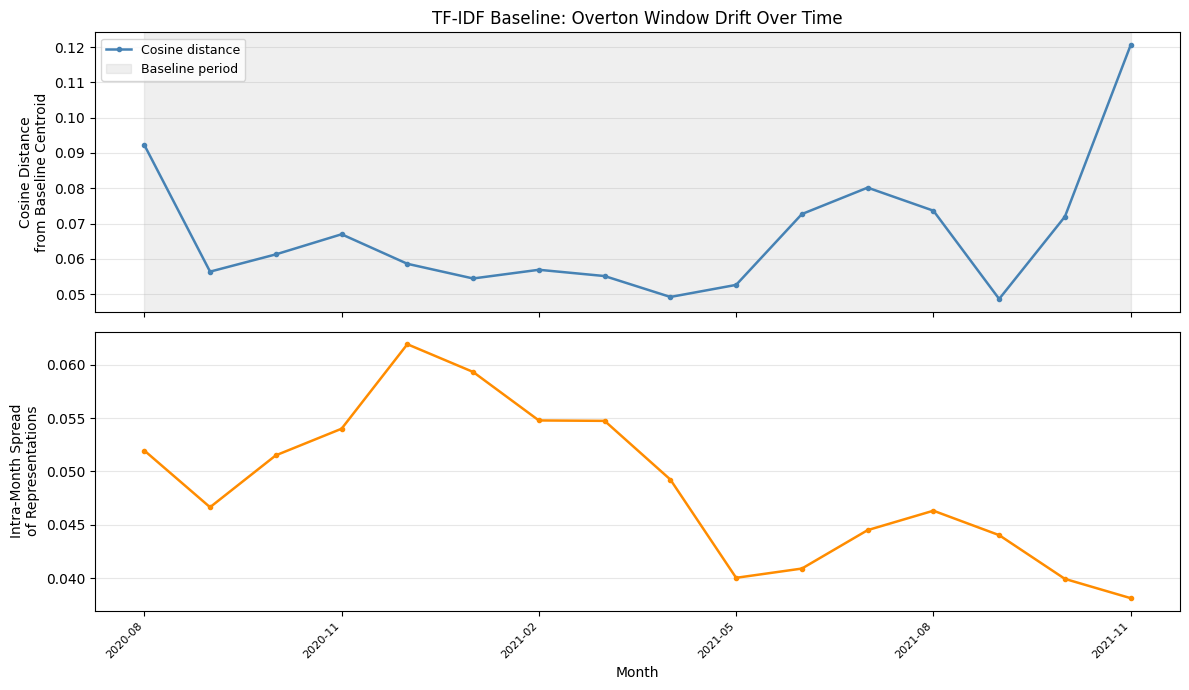

Figure saved as overton_baseline_results.png


In [31]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
months_str = [str(m) for m in df_results['month']]
x = range(len(months_str))

# ── Panel 1: Cosine distance from baseline centroid ──────────────────
axes[0].plot(x, df_results['cosine_dist_baseline'], color='steelblue',
             linewidth=1.8, marker='o', markersize=3, label='Cosine distance')
# Shade the baseline period
baseline_months = df_results[df_results['month'] <= pd.Period(BASELINE_END, freq='M')].index
if len(baseline_months):
    axes[0].axvspan(baseline_months[0], baseline_months[-1], alpha=0.12,
                    color='gray', label='Baseline period')
axes[0].set_ylabel('Cosine Distance\nfrom Baseline Centroid', fontsize=10)
axes[0].set_title('TF-IDF Baseline: Overton Window Drift Over Time', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# ── Panel 2: Intra-month variance (spread) ───────────────────────────
axes[1].plot(x, df_results['intra_month_spread'], color='darkorange',
             linewidth=1.8, marker='o', markersize=3)
axes[1].set_ylabel('Intra-Month Spread\nof Representations', fontsize=10)
axes[1].set_xlabel('Month', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

# X-axis ticks — show every 3rd month to avoid crowding
tick_positions = list(range(0, len(months_str), 3))
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels([months_str[i] for i in tick_positions], rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('overton_baseline_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as overton_baseline_results.png')

## 8. Summary Statistics for Report

In [26]:
print('=== Dataset Statistics (for report Table) ===')
print(f'Total English headlines   : {len(df_en):,}')
print(f'Baseline headlines        : {len(df_baseline):,}')
print(f'Date range                : {df_en.date.min().date()} → {df_en.date.max().date()}')
print(f'Unique sources            : {df_en["source"].nunique():,}')
print(f'\nBaseline centroid drift stats:')
print(df_results['cosine_dist_baseline'].describe().round(4).to_string())

print('\nTop 20 TF-IDF terms in baseline (by mean weight):')
feature_names = tfidf.get_feature_names_out()
top_idx = centroid_baseline.argsort()[-20:][::-1]
print([(feature_names[i], round(centroid_baseline[i], 4)) for i in top_idx])

=== Dataset Statistics (for report Table) ===
Total English headlines   : 92,497
Baseline headlines        : 92,443
Date range                : 2015-04-01 → 2021-11-29
Unique sources            : 2,685

Baseline centroid drift stats:
count    16.0000
mean      0.0670
std       0.0187
min       0.0486
25%       0.0550
50%       0.0599
75%       0.0729
max       0.1206

Top 20 TF-IDF terms in baseline (by mean weight):
[('covid', np.float64(0.0183)), ('new', np.float64(0.0174)), ('news', np.float64(0.0164)), ('19', np.float64(0.0147)), ('covid 19', np.float64(0.0144)), ('fox', np.float64(0.0087)), ('york', np.float64(0.0086)), ('new york', np.float64(0.0086)), ('yahoo', np.float64(0.0082)), ('vaccine', np.float64(0.008)), ('says', np.float64(0.0077)), ('sports', np.float64(0.0077)), ('daily', np.float64(0.0069)), ('times', np.float64(0.0068)), ('cases', np.float64(0.0067)), ('post', np.float64(0.0067)), ('coronavirus', np.float64(0.0063)), ('2021', np.float64(0.0063)), ('cnn', np.float64